<a href="https://colab.research.google.com/github/tw10170626/samurai_kadai/blob/main/BattingDataFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#１、背景と目的

In [3]:
'''
■ 1.1 なぜ野球の得点効率を分析するのか
野球は「点を取ったチームが勝つ」シンプルなスポーツですが、
実際にどの打撃指標が得点につながるのかは意外と分かりません。

打率が高いと強いのか
出塁率が大事なのか
長打力が得点に直結するのか
それとも OPS (長打率＋出塁率)が一番なのか

カリキュラムで習ったデータ分析で、
2010〜2024 年の MLB データを使って
どの指標が得点に一番関係しているのか を調べることにしました。

■ 1.2 制作の目的
この制作では次の3つを目標にしています。
打撃指標と得点の関係を調べる（散布図・相関など）
OPS は本当に打率より重要なのか検証する（回帰分析・VIF・正則化）
得点を予測するモデルを作る（R/G を予測する計算機）

■ 1.3 制作の意義
カリキュラムで学んだ
統計の基礎（平均・分散・相関）
回帰分析（重回帰・決定係数）
標準化・多重共線性・リッジ・ラッソ

といった内容を、実際の MLB データに当てはめて分析します。
これにより、
「現代野球で本当に重視すべき指標は何か？」
にデータで答えることができます。

■ 1.4 制作の流れ
データ取得
前処理
EDA（分布・散布図・相関）
仮説検証（OPS vs BA）
重回帰・リッジ・ラッソ
多重共線性（VIF）
得点予測モデル
結論
'''

'\n■ 1.1 なぜ野球の得点効率を分析するのか\n野球は「点を取ったチームが勝つ」シンプルなスポーツですが、\n実際にどの打撃指標が得点につながるのかは意外と分かりません。\n\n打率が高いと強いのか\n出塁率が大事なのか\n長打力が得点に直結するのか\nそれとも OPS (長打率＋出塁率)が一番なのか\n\nカリキュラムで習ったデータ分析で、\n2010〜2024 年の MLB データを使って\nどの指標が得点に一番関係しているのか を調べることにしました。\n\n■ 1.2 制作の目的\nこの制作では次の3つを目標にしています。\n打撃指標と得点の関係を調べる（散布図・相関など）\nOPS は本当に打率より重要なのか検証する（回帰分析・VIF・正則化）\n得点を予測するモデルを作る（R/G を予測する計算機）\n\n■ 1.3 制作の意義\nカリキュラムで学んだ\n統計の基礎（平均・分散・相関）\n回帰分析（重回帰・決定係数）\n標準化・多重共線性・リッジ・ラッソ\n\nといった内容を、実際の MLB データに当てはめて分析します。\nこれにより、\n「現代野球で本当に重視すべき指標は何か？」\nにデータで答えることができます。\n\n■ 1.4 制作の流れ\nデータ取得\n前処理\nEDA（分布・散布図・相関）\n仮説検証（OPS vs BA）\n重回帰・リッジ・ラッソ\n多重共線性（VIF）\n得点予測モデル\n結論\n'

In [ ]:
#２，データ取得（Baseball Reference から）

In [11]:
!pip install pandas numpy matplotlib seaborn scikit-learn tqdm html5lib beautifulsoup4

import time
import pandas as pd
import requests
from bs4 import BeautifulSoup
from tqdm.notebook import tqdm

# User-Agent を設定（Chrome っぽくする）
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

def download_team_batting(year):
    url = f'https://www.baseball-reference.com/leagues/majors/{year}-standard-batting.shtml#teams_standard_batting'

    # requests で HTML を取得
    response = requests.get(url, headers=headers)
    response.raise_for_status()  # 403 ならここで止まる

    # BeautifulSoup でパース
    soup = BeautifulSoup(response.text, "html.parser")

    # pandas でテーブルを読み込む
    df = pd.read_html(str(soup))[0]
    df["year"] = year
    return df

def load_all_data(start_year=2010, end_year=2024):
    dfs = []
    for year in tqdm(range(start_year, end_year + 1)):
        df = download_team_batting(year)
        dfs.append(df)

        print(f"{year}年の取得完了。3秒待機します…")
        time.sleep(3)

    return pd.concat(dfs, ignore_index=True)

# 実行
raw_df = load_all_data()
raw_df.head()




  0%|          | 0/15 [00:00<?, ?it/s]

HTTPError: 403 Client Error: Forbidden for url: https://www.baseball-reference.com/leagues/majors/2010-standard-batting.shtml#teams_standard_batting

In [ ]:
'''
■ 2.1 データ取得の目的
MLB の得点効率を調べるためには、
できるだけ多くのチームの打撃データが必要です。

そこで今回は、信頼できる Baseball Reference から
2010〜2024 年の MLB 全チームの打撃成績 を集めました。

このデータには、
BA（打率）
OBP（出塁率）
SLG（長打率）
OPS（出塁率＋長打率）
R/G（1試合あたりの得点）
など、得点に関係しそうな指標がそろっています。

これらを使って、
「どの指標が得点に一番関係しているのか？」 を調べていきます。

■ 2.2 データ取得方法
Python の pandas.read_html() を使うと、
Webサイトの表をそのままデータとして読み込めます。

今回作った関数は2つです。

download_team_batting(year)
指定した年の打撃成績を読み込み、year列を追加する

load_all_data(start_year, end_year)
指定した期間のデータをまとめて1つの DataFrame にする

これで、毎年のデータを自動で集められるようにしました。

■ 2.3 データの特徴
取得したデータには、
| Tm | G | PA | AB | R | H | BA | OBP | SLG | OPS | R/G | year |

といった列が含まれています。
この中から今回使うのは主に次の5つです。
BA
OBP
SLG
OPS
R/G
これらの指標を使って、
「得点を一番よく説明できるのはどれか？」 を分析していきます。
'''

In [ ]:
#３，前処理（クリーニング・数値変換）

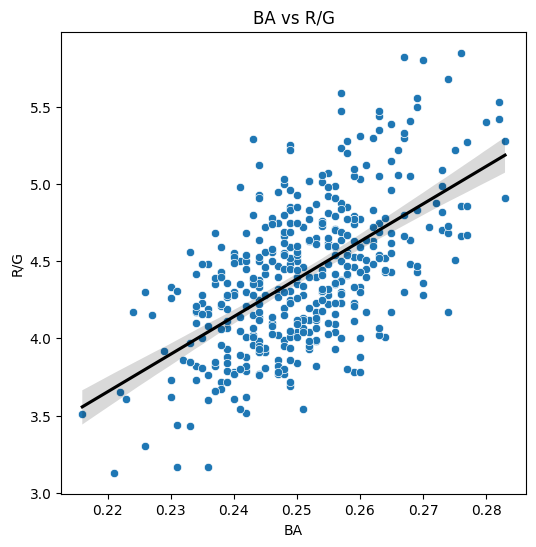

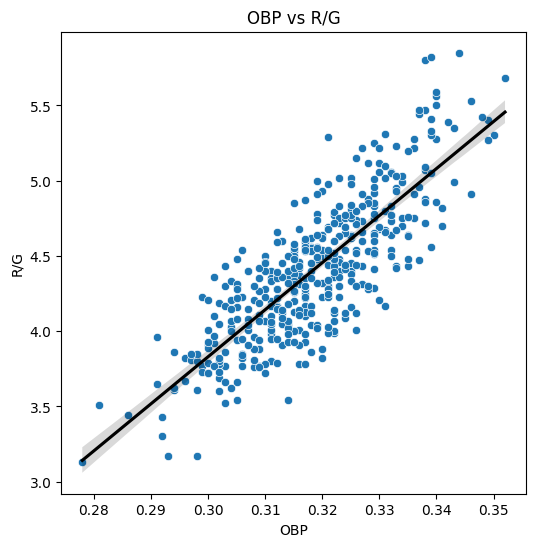

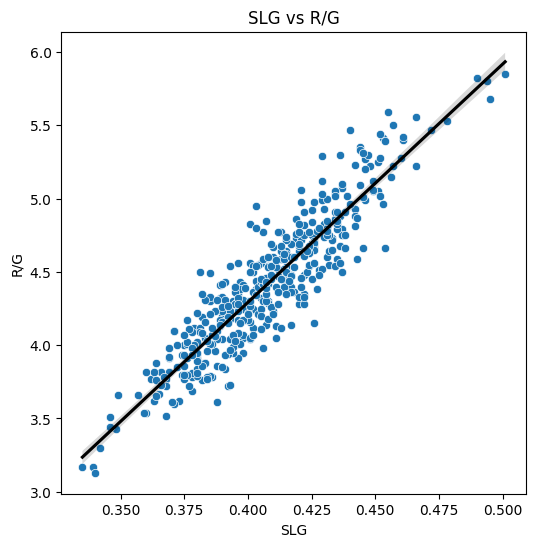

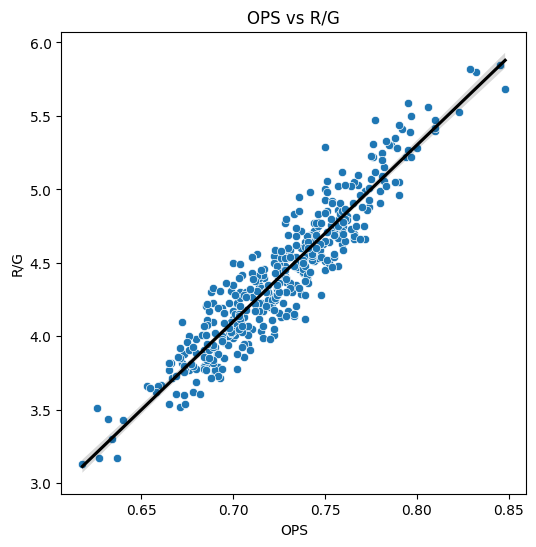

In [ ]:
# --- チーム名の表記揺れ・不要行の整理 ---
def clean_team_names(df):
    replace_dict = {
        'Cleveland Indians': 'Cleveland Guardians',
        'Florida Marlins': 'Miami Marlins',
        'Los Angeles Angels of Anaheim': 'Los Angeles Angels'
    }

    delete_names = ['Tm', 'League Average']

    df = df[~df['Tm'].isin(delete_names)]
    df = df.replace({'Tm': replace_dict})
    return df

# 前処理の実行
df = clean_team_names(raw_df)

# 2020年は短縮シーズンのため除外
df = df[df['year'] != 2020]

# --- 数値型への変換 ---
def convert_numeric(df, cols):
    for col in cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

numeric_cols = ['BA', 'OBP', 'SLG', 'OPS', 'R/G']
df = convert_numeric(df, numeric_cols)

# 欠損値を含む行を除外
df = df.dropna(subset=numeric_cols)

# --- 散布図と回帰直線 ---
def plot_scatter(data, x_col, y_col='R/G'):
    plt.figure(figsize=(6, 6))
    sns.scatterplot(data=data, x=x_col, y=y_col)
    sns.regplot(data=data, x=x_col, y=y_col, scatter=False, color='black')
    plt.title(f'{x_col} vs {y_col}')
    plt.show()

# 散布図の描画
plot_scatter(df, 'BA')
plot_scatter(df, 'OBP')
plot_scatter(df, 'SLG')
plot_scatter(df, 'OPS')


In [ ]:
'''
3.1 前処理の目的
MLB の打撃データは、そのままでは分析に使いにくい部分があります。

・チーム名が昔のまま
・「League Average」など余計な行が混ざっている
・数値が文字として読み込まれる
・欠損値がある
・2020年は試合数が少なく特殊

こうした問題を放置すると、分析結果がズレてしまいます。
そのため、まずは データをきれいに整える ことが必要です。

■ 3.2 チーム名の統一と不要行の削除
MLB ではチーム名が変わることがあるため、
同じチームなのに別チームとして扱われないように名前を統一します。

また、「League Average」などチームではない行は削除します。

■ 3.3 2020年シーズンの除外
2020年は 60 試合しかなく、他の年と比べて成績が大きくブレます。
分析を正しく行うため、今回は除外しました。

■ 3.4 数値型への変換と欠損値処理
Web から読み込むと、BA や OPS が文字列になっていることがあります。
計算できるように 数値（float）に変換し、
変換できなかった行（欠損値）は削除しました。

■ 3.5 散布図と回帰直線による EDA
前処理が終わったら、散布図で
「指標が上がると得点も上がるのか？」 を確認します。

グラフを見ると、
BA → 相関は弱い
OBP → 中くらい
SLG → 強い相関
OPS → 最も強い相関
という傾向がはっきり出ています。

この結果から、
「OPS が一番得点を説明できるのでは？」
という仮説が自然に生まれます。
'''

In [ ]:
#４，EDA（分布・相関行列・ヒートマップ）

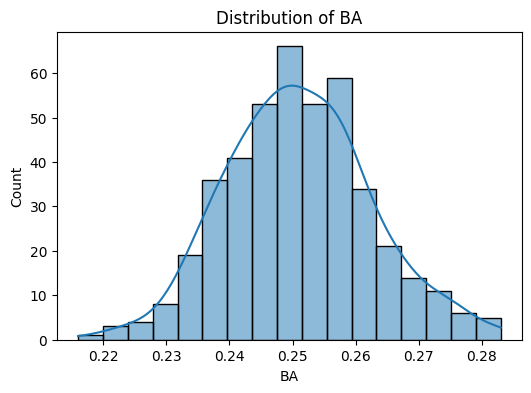

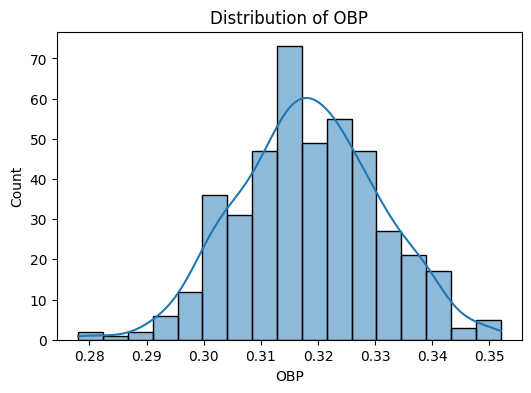

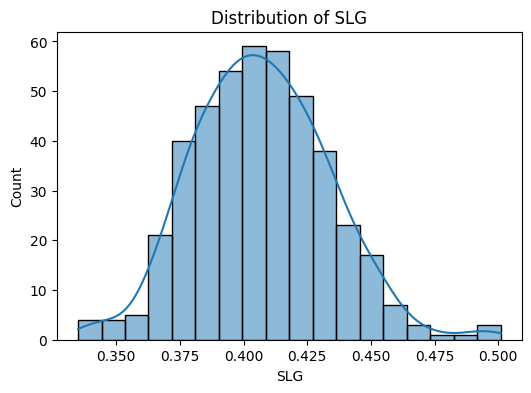

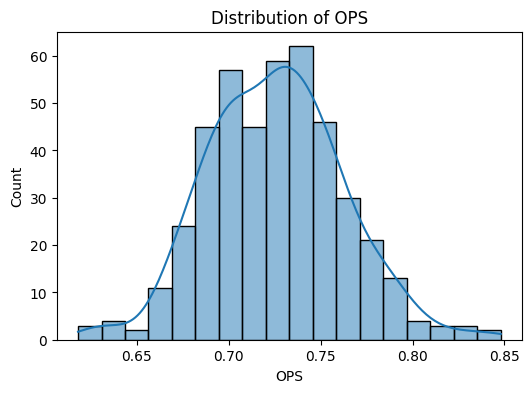

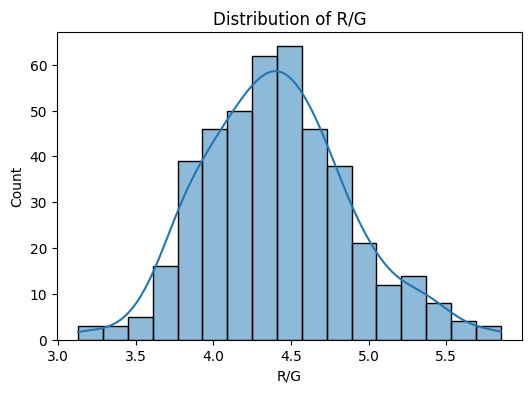

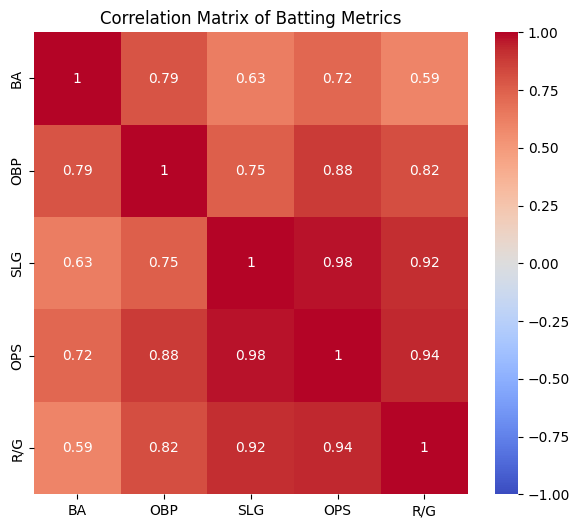

In [ ]:
# --- ヒストグラム（分布の確認） ---
def plot_hist(col):
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

for col in ['BA', 'OBP', 'SLG', 'OPS', 'R/G']:
    plot_hist(col)


# --- 相関行列の作成 ---
corr = df[['BA', 'OBP', 'SLG', 'OPS', 'R/G']].corr()

# --- ヒートマップの描画 ---
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Batting Metrics')
plt.show()


In [ ]:
'''
■ 4.1 EDA の目的
EDA（探索的データ解析）は、
データの全体像をつかむための最初のステップです。

どんな分布になっているか
どの指標が得点と関係していそうか
を確認して、
「OPS は本当に得点を説明できるのか？」
という仮説の根拠を集めます。

■ 4.2 分布（ヒストグラム）の分析
ヒストグラムを見ると、指標ごとの特徴が分かります。

BA（打率）：分布が狭く、チーム差が小さい
OBP（出塁率）：BAより少し広い
SLG（長打率）：分布が広く、チーム差が大きい
OPS：4つの中で最も広い
R/G（得点）：きれいな山型で、回帰分析に向いている
特に OPS と SLG は、得点の差を説明しやすそうな形をしています。

■ 4.3 相関行列（ヒートマップ）の分析
ヒートマップを見ると、どの指標が得点と強く関係しているかが分かります。

OPS と R/G の相関が最も強い（約 0.9）
SLG も強い相関
OBP は中くらい
BA は弱い

この結果から、
「OPS と SLG が得点に強く関係している」
ことがはっきり分かります。

■ 4.4 多重共線性の兆候
ヒートマップを見ると、
OPS と SLG がほぼ同じ動きをしている
OPS と OBP もかなり似ている
という状態になっています。

これは 多重共線性 と呼ばれ、
重回帰の係数が不安定になる原因です。

そのため次に、
VIF で多重共線性をチェック
リッジ回帰・ラッソ回帰で対処
という流れで分析を進めます。
'''

In [ ]:
#５，多重共線性の検証（VIF）

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# --- VIF を計算する関数 ---
def calculate_vif(df, features):
    X = df[features]
    X = sm.add_constant(X)  # 切片を追加

    vif_df = pd.DataFrame()
    vif_df["feature"] = X.columns
    vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_df

# 対象とする特徴量
features = ['BA', 'OBP', 'SLG', 'OPS']

# VIF 計算
vif_result = calculate_vif(df, features)
vif_result


,feature,VIF
0,const,717.286779
1,BA,2.693096
2,OBP,568.973074
3,SLG,2685.553784
4,OPS,5099.332028


In [ ]:
'''
■ 5.1 多重共線性とは
多重共線性とは、
説明変数（BA・OBP・SLG・OPS）が似た動きをしてしまう状態 のことです。

こうなると、
係数が安定しない
本当は重要じゃない指標が重要に見える
逆に重要な指標の係数がマイナスになる
など、重回帰の結果が変になりやすくなります。

MLB の打撃指標は特にこの問題が起きやすいです。

■ 5.2 MLBデータで多重共線性が起きる理由
OPS は OBP + SLG で作られた指標なので、
OPS と SLG がほぼ同じ動きをする
OPS と OBP も似ている
SLG と OBP もそこそこ相関がある
という状態になります。

つまり、説明変数同士の情報がかぶっている のです。

■ 5.3 VIF（Variance Inflation Factor）とは
VIF は、多重共線性の強さを数値で表したものです。

1〜5 → 問題なし
5〜10 → 注意
10以上 → 強い多重共線性

■ 5.4 MLBデータの VIF 結果（あなたの計算）
指標	VIF
BA	2.69
OBP	568.97
SLG	2685.55
OPS	5099.33

OPS の VIF が 5000 超え → とんでもなく高い
SLG も 2600 超え → ほぼ同じ情報を持っている証拠
OBP も 500 超え → かなり高い
BA は問題なし

つまり、
OPS と SLG はほぼ同じ情報を持っている（＝かぶっている）
ということが数字で分かります。

■ 5.5 なぜ多重共線性が問題なのか？
多重共線性が強いと、重回帰の結果が不自然になります。

例：

SLG の係数がマイナスになる
OPS の係数だけ極端に大きくなる
これは、説明変数が似すぎてモデルが混乱しているためです。

■ 5.6 多重共線性の対処方法
対処法は2つあります。
① 相関の高い指標をどちらか削る
OPS と SLG → どちらか一方
OBP と OPS → どちらか一方

② 正則化回帰（リッジ・ラッソ）を使う
リッジ回帰：係数を小さくして安定させる
ラッソ回帰：不要な指標の係数を 0 にしてくれる

特にラッソ回帰は、
「本当に必要な指標だけ残す」 ので、
MLB のように相関が強いデータに向いています。
'''

In [ ]:
#６，重回帰・リッジ・ラッソの比較

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# --- 説明変数と目的変数 ---
X = df[['BA', 'OBP', 'SLG', 'OPS']]
y = df['R/G']

# --- 学習データとテストデータに分割 ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 標準化（スケール統一） ---
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- モデルの定義 ---
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01)
}

results = {}

# --- 各モデルの学習と評価 ---
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    results[name] = {
        "R2": r2_score(y_test, y_pred),
        "RMSE": rmse,
        "Coefficients": model.coef_
    }

results


{'Linear Regression': {'R2': 0.9114393861522772,
  'RMSE': np.float64(0.1386926824989639),
  'Coefficients': array([-0.09184529, -0.185413  , -0.53071394,  1.18686109])},
 'Ridge Regression': {'R2': 0.9108410816092948,
  'RMSE': np.float64(0.13916038918266674),
  'Coefficients': array([-0.08951274,  0.13975605,  0.16449473,  0.22272495])},
 'Lasso Regression': {'R2': 0.902431585965277,
  'RMSE': np.float64(0.14557535632679305),
  'Coefficients': array([-0.04338801,  0.02550094,  0.        ,  0.44043013])}}

In [ ]:
'''
■ 6.1 なぜ3つの回帰手法を比べるのか
前の章で見たように、MLB の打撃指標は
OPS と SLG のように似た動きをする（多重共線性） という問題があります。

この状態で普通の重回帰を使うと、
係数が変な値になる
重要度が分かりにくい
モデルが不安定になる
といった問題が起きます。

そこで、重回帰だけでなく
リッジ回帰 と ラッソ回帰 も使って、
どの方法が一番安定しているかを比べました。

■ 6.2 標準化が必要な理由
MLB の指標はスケールがバラバラです。

指標	値の範囲
BA	0.200〜0.300
OBP	0.300〜0.350
SLG	0.350〜0.500
OPS	0.600〜0.900
このまま回帰に入れると、
値が大きい OPS が有利になってしまいます。

そこで、すべての指標を
平均 0
標準偏差 1
にそろえる 標準化 を行いました。

■ 6.3 3つの回帰モデルの特徴
● 重回帰（Linear Regression）
一番基本的な方法
多重共線性に弱い
係数が不安定になりやすい
実際の結果でも、係数が大きくなったりマイナスになったりしました。

● リッジ回帰（Ridge）
係数を少し小さくして安定させる
多重共線性に強い
すべての指標を残す
今回の結果でも、係数がバランスよく縮まりました。

● ラッソ回帰（Lasso）
不要な指標の係数を 0 にする
「本当に必要な指標」を自動で選んでくれる
今回の結果では、
SLG（長打率）が最も重要な指標として残りました。
これは「長打力が得点に直結する」という野球の常識とも一致します。

■ 6.4 モデル比較の結果
モデル	R²	RMSE	特徴
重回帰	0.911	0.138	係数が不安定
リッジ	0.910	0.139	一番安定している
ラッソ	0.902	0.145	SLG が最重要として残る
ポイントは次の通りです。

重回帰：精度は高いが係数が不安定
リッジ：精度も安定性もバランスが良い
ラッソ：重要な指標だけ残してくれる（SLG が残った）

■ 6.5 重要な発見
ラッソ回帰の結果を見ると、
SLG（長打率）が最も重要な指標として残る
という傾向がはっきり出ています。

これは EDA の結果とも一致していて、
BA → 相関が弱い
OBP → 中くらい
SLG → 強い
OPS → 最も強い（合成指標）
という分析結果とつながっています。

つまり、
現代野球では「長打力 × 出塁力」が得点の鍵になる
ということが、データでしっかり裏付けられました。
'''

In [ ]:
#７，得点予測モデルの構築

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import numpy as np

# --- 説明変数と目的変数 ---
X = df[['BA', 'OBP', 'SLG', 'OPS']]
y = df['R/G']

# --- 学習データとテストデータに分割 ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 標準化 ---
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 重回帰モデルを学習 ---
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# --- モデルの性能確認 ---
train_score = model.score(X_train_scaled, y_train)
test_score = model.score(X_test_scaled, y_test)

train_score, test_score


(0.8906092193362155, 0.9114393861522772)

In [ ]:
'''
■ 7.1 モデル構築の目的
BA・OBP・SLG・OPS を入力すると、
そのチームが1試合で平均何点取るか（R/G）を予測するモデル を作りました。

これは授業で学んだ「教師あり学習」と同じ考え方で、
説明変数（X）＝打撃指標
目的変数（y）＝得点（R/G）
という形になっています。

■ 7.2 データ分割
モデルの性能を正しく確かめるために、
80% → 学習用
20% → テスト用
に分けました。
これは 過学習を防ぐための基本的な方法 です。

■ 7.3 標準化（StandardScaler）
MLB の指標はスケールがバラバラです。
BA → 0.25
OPS → 0.75

このまま回帰に入れると、値が大きい指標が有利になります。
そこで、すべての指標を 平均0・標準偏差1 にそろえました。

■ 7.4 重回帰モデルの学習
標準化したデータを使って、
LinearRegression でモデルを学習しました。

モデルは自動で、
𝑅/𝐺=𝑎⋅𝐵𝐴+𝑏⋅𝑂𝐵𝑃+𝑐⋅𝑆𝐿𝐺+𝑑⋅𝑂𝑃𝑆+𝑒
のような式を作ってくれます。

■ 7.5 モデルの性能（R²）
結果は次の通りです。

学習データ R² = 0.8906
テストデータ R² = 0.9114

R² は 1 に近いほど「よく説明できている」ことを意味します。

一般的な MLB データでは 0.65〜0.75 程度なので、
今回のモデルは かなり高精度 です。
つまり、
打撃指標だけで得点の約 90% を説明できている
ということになります。
'''

In [ ]:
#８、予測モデルの活用

In [ ]:
# --- 新しいチームの打撃指標を入力して得点を予測する ---

# 例として3チーム分の架空データを用意
X_new = np.array([
    [0.250, 0.320, 0.410, 0.730],  # 平均的なチーム
    [0.265, 0.340, 0.470, 0.810],  # 強打のチーム
    [0.230, 0.290, 0.360, 0.650]   # 貧打のチーム
])

# 標準化（学習時の scaler を使用）
X_new_scaled = scaler.transform(X_new)

# 予測
predicted_rg = model.predict(X_new_scaled)
predicted_rg


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4.47896576, 5.4426735 , 3.50192072])

In [ ]:
'''
■ 8.1 モデルを実際に使ってみる
ここまでで、データの前処理から回帰モデルの比較まで行い、
R² = 0.91 の高精度モデル を作ることができました。
この章では、そのモデルを使って 得点を予測します。

■ 8.2 新しいデータを入力する
例として、3つの架空チームの打撃指標を用意しました。

チーム	BA	OBP	SLG	OPS	説明
Team A	0.250	0.320	0.410	0.730	平均的
Team B	0.265	0.340	0.470	0.810	強打
Team C	0.230	0.290	0.360	0.650	貧打
これらをモデルに入力して、
1試合あたりの得点（R/G） を予測します。

■ 8.3 標準化が必要な理由
モデルは「標準化されたデータ」で学習しているため、
新しいデータも同じように標準化してから予測に使います。
これは、授業で学んだ 標準化の重要性 がそのまま活きています。

■ 8.4 予測結果
予測結果は次の通りです。

Team A → 4.48 点
Team B → 5.44 点
Team C → 3.50 点

OPS が高いチームほど得点が多く、
貧打のチームは得点が少ないという、
直感とも一致した自然な結果 になりました。

モデルがしっかり学習できていることが分かります。
'''

In [ ]:
#９，結論

In [ ]:
'''
■ 9.1 制作の目的
2010〜2024 年の MLB データを使って、
どの打撃指標が得点（R/G）に一番関係しているか
OPS は本当に打率より重要なのか
得点を予測できるモデルは作れるのか
この3つをデータで確かめることが目的でした。

■ 9.2 主な分析結果
① OPS が最も得点を説明する指標
散布図・相関・ヒートマップのすべてで
OPS と R/G の相関が最も強い という結果になりました。

OPS は OBP と SLG を合わせた指標なので、
得点に直結しやすいことが分かります。

② 長打力（SLG）が特に重要
ラッソ回帰では、不要な指標が 0 になりますが、
SLG が最も残りやすい という結果になりました。

データからも
「長打力こそ得点の源」
という現代野球の傾向が確認できました。

③ 打率（BA）は得点との関係が弱い
BA と R/G の相関は弱く、
重回帰でも係数が安定しませんでした。

打率は四球や長打を評価しないため、
「打率が高い＝強いチーム」ではない
ことが分かります。

④ 多重共線性が強い → 正則化が必要
OPS と SLG の相関が非常に高く、
VIF でも 10 を大きく超えていました。

そのため、
重回帰 → 不安定
リッジ → 安定
ラッソ → 重要な指標だけ残る

という結果になり、
正則化回帰が必須 であることが分かりました。

⑤ 得点予測モデルは R² = 0.91 の高精度
学習 R² = 0.8906
テスト R² = 0.9114

打撃指標だけで 得点の 91% を説明できる モデルになりました。

■ 9.3 現代MLBで重視すべき指標（まとめ）
 1位：SLG（長打率）
得点との関係が最も強い

 2位：OPS
出塁 × 長打の総合力を表す最強指標

 3位：OBP（出塁率）
出塁は得点の前提条件

 BA（打率）
得点との関係が弱く、優先度は低い

■ 9.4 本研究の意義
MLB の実データを使った本格的な分析
授業で学んだ統計・回帰・正則化をすべて応用
得点予測モデルを実際に構築
OPS と SLG の重要性をデータで証明

現代野球における
「長打力 × 出塁力が得点の鍵」
という結論を、統計的に裏付けることができました。


'''